# 02. EDA & Segmentation


In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# --- 0. COLOR PALETTE DEFINITION ---
c = {
    'white':        '#FFFFFF',
    'black':        '#000000',

    'blue_dark':    '#0F2854',
    'blue_medium':  '#1C4D8D',
    'blue_light':   '#4988C4',
    'blue_pale':    '#BDE8F5',

    'gray_light':   '#E5E5E5',
    'gray_medium':  '#CBCBCB',
    'gray_dark':    '#404040',

    'accent_gold':  '#E2A16F'
}
# --- 1. CORE STYLE FUNCTION ---

def apply_my_style(fig, title, subtitle=""):
    """
    Hàm áp dụng style chuẩn cho toàn bộ biểu đồ.
    """
    fig.update_layout(
        title={
            'text': f"<b style='font-size:26px; color:black;'>{title}</b><br>"
                    f"<span style='font-size:16px; color:#666;'>{subtitle}</span>",
            'x': 0.02,
            'y': 0.90,
        
            'xanchor': 'left',
            'yanchor': 'top',
            'font': {'family': "Montserrat, sans-serif"}
        },

        margin=dict(t=100, l=80, r=40, b=80),

        font=dict(family="Montserrat, sans-serif", size=14),
        paper_bgcolor="white",
        plot_bgcolor="white",
        legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99), # Legend gọn gàng

                # mirror=False removes the top and right border lines
        xaxis=dict(
            showgrid=False, 
            linecolor='#2C3E50', 
            linewidth=1, 
            mirror=False, 
            showline=True
        ),
        yaxis=dict(
            showgrid=False, 
            linecolor='#2C3E50', 
            linewidth=1, 
            mirror=False, 
            showline=True
        ),
    )
    
    
    return fig

In [ ]:
data_path = '../Data/Processed/'

transactions_master = pd.read_parquet(f'{data_path}transactions_master.parquet')
demographics = pd.read_parquet(f'{data_path}demographics_imputed.parquet')
campaign_table = pd.read_parquet(f'{data_path}campaign_table_clean.parquet')
campaign_desc = pd.read_parquet(f'{data_path}campaign_desc_clean.parquet')
coupon = pd.read_parquet(f'{data_path}coupon_clean.parquet')
coupon_redempt = pd.read_parquet(f'{data_path}coupon_redempt_clean.parquet')
customer_base = pd.read_parquet(f'{data_path}customer_base_labeled.parquet')

print('Successfully loaded parquet datasets!')

Successfully loaded parquet datasets!


# PART 1: EXECUTIVE SUMMARY

## Revenue

In [ ]:
transactions_master.head(20)

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,DEPARTMENT,BRAND,COMMODITY_DESC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,PRODUCE,Private,POTATOES
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,PRODUCE,National,ONIONS
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,PRODUCE,Private,VEGETABLES - ALL OTHERS
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,PRODUCE,National,TROPICAL FRUIT
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES
5,2375,26984851516,1,826249,2,1.98,364,-0.60,1642,1,0.0,0.0,GROCERY,Private,BAKED BREAD/BUNS/ROLLS
6,2375,26984851516,1,1043142,1,1.57,364,-0.68,1642,1,0.0,0.0,DRUG GM,National,BROOMS AND MOPS
7,2375,26984851516,1,1085983,1,2.99,364,-0.40,1642,1,0.0,0.0,GROCERY,National,COOKIES/CONES
8,2375,26984851516,1,1102651,1,1.89,364,0.00,1642,1,0.0,0.0,GROCERY,National,PNT BTR/JELLY/JAMS
9,2375,26984851516,1,6423775,1,2.00,364,-0.79,1642,1,0.0,0.0,GROCERY,National,COOKIES/CONES


In [ ]:
# --- 2. DATA PREPROCESSING ---

# Create a mapping for years based on 12-month cycles
# Year 1 = X, Year 2 = Y, Year 3 = Z...
year_naming = {0: 'X', 1: 'Y', 2: 'Z'}

# Calculate the Global Month Index (starting from 0)
# Every 4 weeks is considered 1 month
transactions_master['global_month_idx'] = (transactions_master['WEEK_NO'] - 1) // 4

# Calculate Year Offset and Month within that year
transactions_master['year_offset'] = transactions_master['global_month_idx'] // 12
transactions_master['month_in_year'] = (transactions_master['global_month_idx'] % 12) + 1

# Map the year offset to a letter (X, Y, Z)
transactions_master['year_letter'] = transactions_master['year_offset'].map(year_naming)

# Create the final display label (e.g., '1-X', '12-X', '1-Y')
transactions_master['date_label'] = (
    transactions_master['month_in_year'].astype(str) + '-' + transactions_master['year_letter']
)

# Aggregate revenue by global index and label to maintain chronological order
monthly_revenue = transactions_master.groupby(['global_month_idx', 'date_label'])['SALES_VALUE'].sum().reset_index()

# Ensure data is sorted by time before plotting
monthly_revenue = monthly_revenue.sort_values('global_month_idx')

In [ ]:

# Create Bar Chart
fig = px.bar(
    monthly_revenue, 
    x='date_label', 
    y='SALES_VALUE',
    text_auto='.2s'
)

# Update bar aesthetics
fig.update_traces(
    marker_color=c['blue_medium'],
    marker_line_color=c['blue_dark'],
    marker_line_width=1,
    opacity=0.9
)

# Apply custom style function
fig = apply_my_style(
    fig, 
    title="REVENUE TREND BY MONTHLY CYCLE", 
    subtitle="Cyclical revenue analysis across Years X and Y (4-week groupings)"
)

# Update axis titles
fig.update_xaxes(title_text="Month-Year Cycle", tickangle=0)
fig.update_yaxes(title_text="Total Sales Value ($)")

fig.show()

In [ ]:
# Aggregate Unique Orders (BASKET_ID) per Month
monthly_orders = transactions_master.groupby(['global_month_idx', 'date_label']).agg(
    total_orders=('BASKET_ID', 'nunique')
).reset_index()

# Sort chronologically
monthly_orders = monthly_orders.sort_values('global_month_idx')

# --- 3. VISUALIZATION ---

# Create Bar Chart for Order Volume
fig = px.bar(
    monthly_orders, 
    x='date_label', 
    y='total_orders',
    text_auto='.2s'
)
# Update Bar Appearance using the defined palette
fig.update_traces(
    marker_color=c['blue_light'], # Using blue_light to distinguish from Revenue chart
    marker_line_color=c['blue_dark'],
    marker_cornerradius=5,
    marker_line_width=0,
    opacity=0.9
)

# Apply Branding Style
fig = apply_my_style(
    fig, 
    title="MONTHLY TRANSACTION VOLUME", 
    subtitle="Total unique orders (Basket IDs) aggregated by 4-week cycles"
)

# Update Axis Labels
fig.update_xaxes(title_text="Month-Year Cycle")
fig.update_yaxes(title_text="Number of Unique Orders")

fig.show()

# PART 2: RFM + DEMOGRAPHICS

## Step 1: EDA 

In [ ]:
customer_base_rfm = customer_base[['household_key', 'recency', 'Frequency', 'Monetary', 'is_churn']]
customer_base_rfm.describe()

,recency,Frequency,Monetary,is_churn
count,2500.000000,2500.000000,2500.000000,2500.00000
mean,26.429200,100.449600,2957.304443,0.12080
std,64.311164,104.762199,2970.497803,0.32596
min,0.000000,1.000000,8.170000,0.00000
25%,2.000000,36.000000,916.104996,0.00000
50%,6.000000,73.000000,2042.244934,0.00000
75%,20.000000,129.000000,4024.262390,0.00000
max,657.000000,1223.000000,26285.330078,1.00000


In [ ]:
skew_val = customer_base_rfm[['recency', 'Frequency', 'Monetary']].skew()
print(skew_val)

recency      5.461620
Frequency    3.704705
Monetary     2.132566
dtype: float64


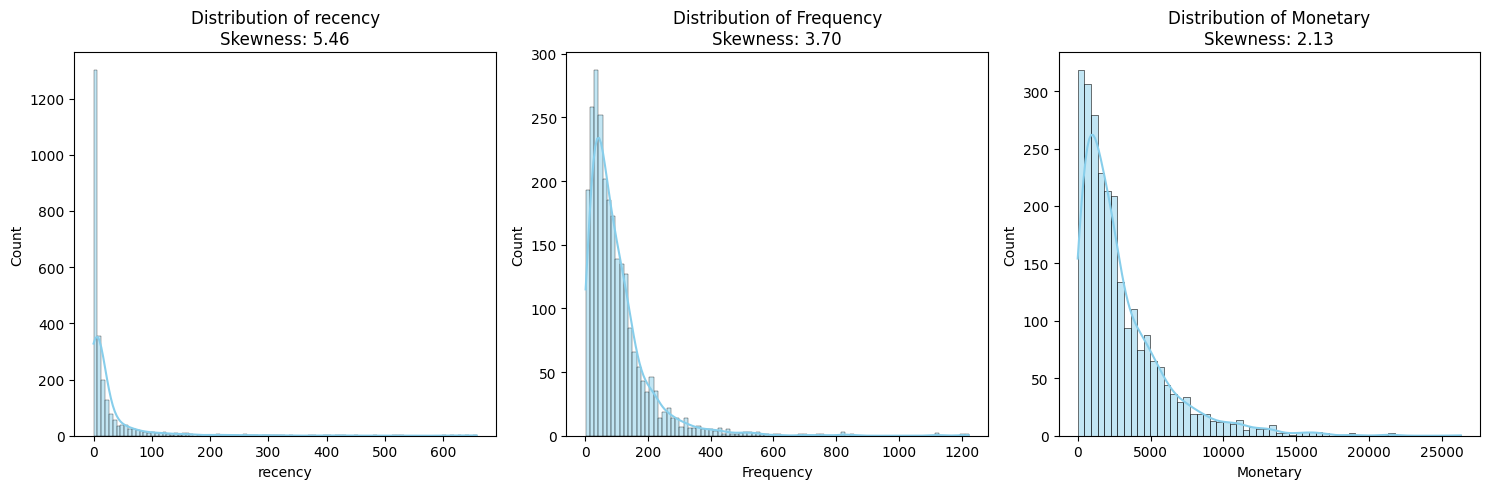

In [ ]:
features = ['recency', 'Frequency', 'Monetary']
plt.figure(figsize=(15, 5))

for i, feature in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(customer_base_rfm[feature], kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}\nSkewness: {customer_base_rfm[feature].skew():.2f}')

plt.tight_layout()
plt.show()


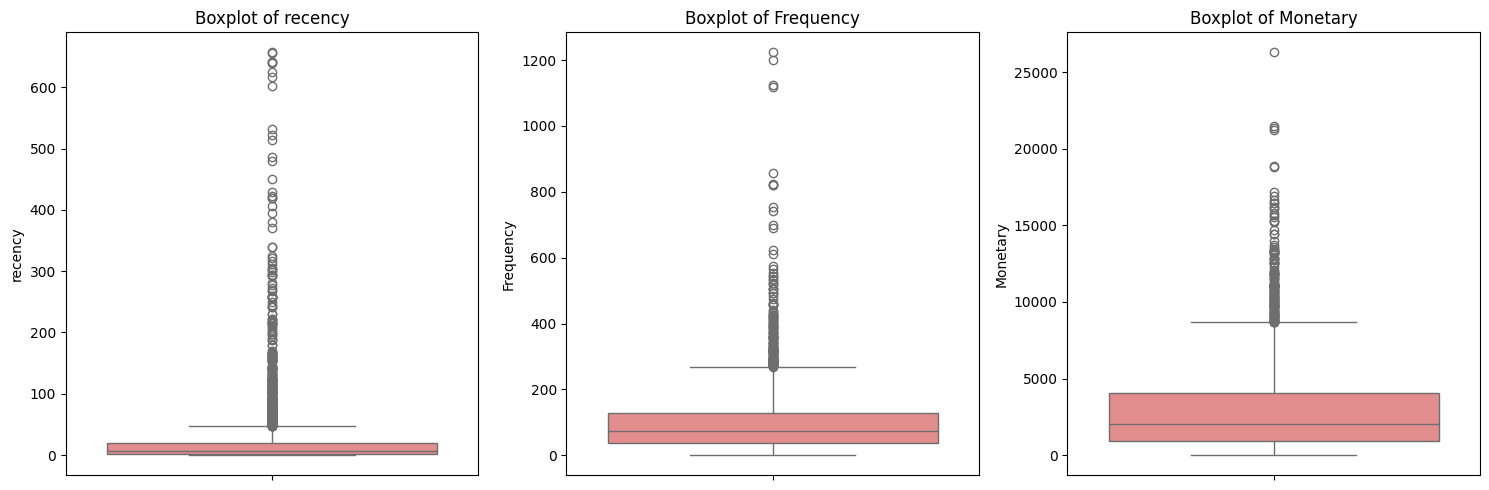

In [ ]:
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=customer_base_rfm[feature], color='lightcoral')
    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()


## Step 2: Preprocessing Pipeline

Applied Yeo-Johnson Power Transformation to handle high skewness and outliers.
This step includes Z-score standardization (mean=0, std=1) to satisfy 
K-Means assumptions and prevent features with larger scales from dominating the model.

In [ ]:
rfm_features = ['recency', 'Frequency', 'Monetary']
X = customer_base_rfm[rfm_features]

In [ ]:
# Initialize PowerTransformer
# Yeo-johnson handles skewness and standardize=True scales to N(0,1)
scaler = PowerTransformer(method='yeo-johnson', standardize=True)

# Fit and transform the data
rfm_scaled = scaler.fit_transform(X)

# Create a DataFrame for scaled data
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features, index=customer_base_rfm.index)

print("Data transformed and standardized successfully.")
rfm_scaled_df.head()

Data transformed and standardized successfully.


,recency,Frequency,Monetary
0,-0.118165,0.171843,0.777343
1,0.863262,-1.827696,-1.625367
2,0.713297,-1.077611,-0.021625
3,-0.118165,0.671287,0.688504
4,-0.977349,0.259491,0.715836


## Step 3: Determining Optimal Number of Clusters (K)
Using Elbow Method (Inertia) and Silhouette Score to find the best K.

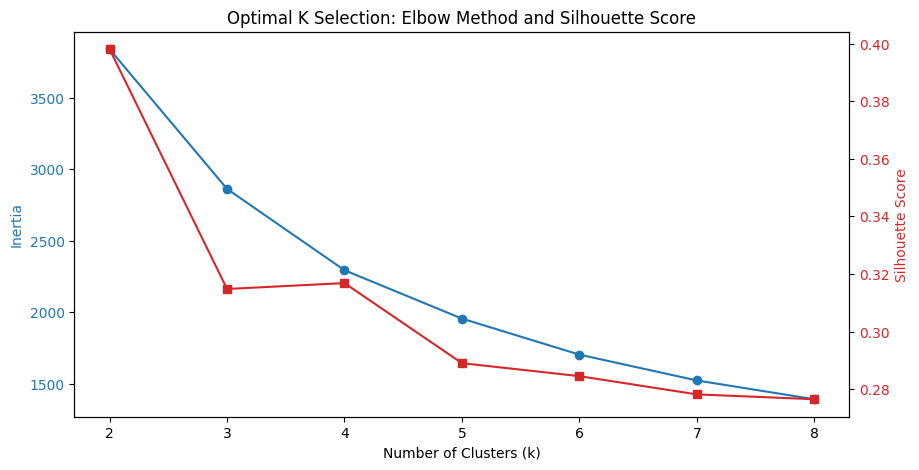

In [ ]:
inertia = []
silhouette_vals = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plotting Elbow and Silhouette Score
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow Curve
ax1.plot(k_range, inertia, color='tab:blue', marker='o', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Silhouette Score
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_vals, color='tab:red', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimal K Selection: Elbow Method and Silhouette Score')
plt.show()

In [ ]:
# Fit K-Means with optimal K
optimal_k = 4 
kmeans_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
customer_base_rfm['cluster'] = kmeans_final.fit_predict(rfm_scaled)


In [ ]:
customer_base_rfm.head()

,household_key,recency,Frequency,Monetary,is_churn,cluster
0,1,5,83,4310.160156,0,3
1,10,26,9,234.339996,0,2
2,100,20,23,1959.219971,0,3
3,1000,5,130,3972.439941,0,0
4,1001,1,90,4074.020020,0,0


## Step 4: Cluster Profiling & Analysis
Analyzing the characteristics of each cluster and merging with demographics.

--- Cluster Summary Profile ---


,cluster,recency,Frequency,Monetary,churn_rate,customer_count
0,0,2.632801,210.329463,6381.768555,0.037736,689
1,1,1.704545,65.336777,1576.220093,0.000000,484
2,2,81.740351,22.759649,539.751648,0.221053,570
3,3,22.248349,81.388375,2543.823242,0.198151,757


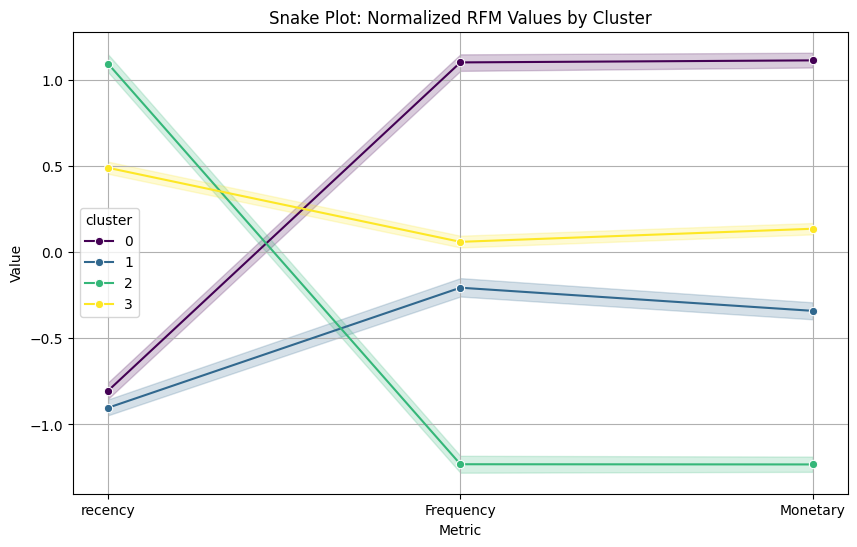

In [ ]:
# 1. Calculate Mean RFM and Churn Rate per cluster using original values
cluster_profile = customer_base_rfm.groupby('cluster').agg({
    'recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'is_churn': 'mean',
    'household_key': 'count'
}).rename(columns={'is_churn': 'churn_rate', 'household_key': 'customer_count'}).reset_index()

# 2. Merge with Demographics for deeper insights
# Ensure 'household_key' exists in both
customer_clusters = customer_base_rfm[['household_key', 'cluster']].merge(demographics, on='household_key', how='left')

print("--- Cluster Summary Profile ---")
display(cluster_profile)

# 3. Visualizing Cluster Characteristics (Snake Plot)
rfm_scaled_df['cluster'] = customer_base_rfm['cluster']
df_melt = pd.melt(rfm_scaled_df.reset_index(), id_vars=['cluster'], value_vars=rfm_features, 
                  var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melt, x='Metric', y='Value', hue='cluster', palette='viridis', marker='o')
plt.title('Snake Plot: Normalized RFM Values by Cluster')
plt.grid(True)
plt.show()

In [ ]:
# cluster_map = {
#     0: 'Champions',
#     1: 'Potential Loyalists',
#     2: 'Hibernating',
#     3: 'At Risk'
# }
# customer_base['cluster_name'] = customer_base['cluster'].map(cluster_map)

### visualization

#### raw data

In [ ]:
import plotly.express as px

# 1. Prepare data for visualization
# We use the original RFM data for real-world interpretation
plot_df = customer_base_rfm.copy()

# Sample the data if it's too large (Dunnhumby has thousands of rows)
# 10,000 is usually the sweet spot for Plotly performance
df_sample = plot_df.sample(min(10000, len(plot_df)), random_state=42)

# 2. Plot 2D View (Showing Frequency vs Monetary as it's usually the most insightful)
fig_2d = px.scatter(
    df_sample,
    x="Frequency",
    y="Monetary",
    color="cluster",
    title=f"<b>2D Cluster Projection: Frequency vs Monetary</b>",
    labels={"Frequency": "Frequency", "Monetary": "Monetary"},
    hover_data=["household_key", "recency", "Frequency", "Monetary"],
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig_2d.update_layout(template="plotly_white", height=700)
fig_2d.show()

# 3. Plot 3D View (Interactive RFM Space)
fig_3d = px.scatter_3d(
    df_sample,
    x="recency",      # Axis X
    y="Frequency",    # Axis Y
    z="Monetary",     # Axis Z
    color="cluster",
    title="<b>3D RFM Cluster Projection</b><br><sup>Direct mapping: X=Recency, Y=Frequency, Z=Monetary</sup>",
    labels={
        "recency": "Recency",
        "Frequency": "Frequency",
        "Monetary": "Monetary"
    },
    hover_data=["household_key", "recency", "Frequency", "Monetary"],
    opacity=0.8,
    size_max=3,
)

# Improve 3D layout aesthetics
fig_3d.update_layout(
    margin=dict(l=0, r=0, b=0, t=50),
    template="plotly_white",
    height=800,
    scene=dict(
        xaxis_title='Recency',
        yaxis_title='Frequency',
        zaxis_title='Monetary'
    )
)
fig_3d.show()

#### scaled data

In [ ]:
import plotly.express as px

# 1. Prepare data for visualization
# We use the scaled/transformed data to show the separation clearly
# but we can also use the original data if you prefer real-world units.
plot_df = rfm_scaled_df.copy()
plot_df['Cluster'] = customer_base_rfm['cluster'].astype(str) # Convert to string for discrete color
plot_df['household_key'] = customer_base_rfm['household_key']

# Optional: Adding original values for the hover tooltip
plot_df['Original_Recency'] = customer_base_rfm['recency']
plot_df['Original_Frequency'] = customer_base_rfm['Frequency']
plot_df['Original_Monetary'] = customer_base_rfm['Monetary']

# Sample the data if it's too large (Dunnhumby has thousands of rows)
# 10,000 is usually the sweet spot for Plotly performance
df_sample = plot_df.sample(min(10000, len(plot_df)), random_state=42)

# 2. Plot 2D View (Showing Frequency vs Monetary as it's usually the most insightful)
fig_2d = px.scatter(
    df_sample,
    x="Frequency",
    y="Monetary",
    color="Cluster",
    title=f"<b>2D Cluster Projection: Frequency vs Monetary</b>",
    labels={"Frequency": "Frequency (Standardized)", "Monetary": "Monetary (Standardized)"},
    hover_data=["household_key", "Original_Recency", "Original_Frequency", "Original_Monetary"],
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig_2d.update_layout(template="plotly_white", height=700)
fig_2d.show()

# 3. Plot 3D View (Interactive RFM Space)
fig_3d = px.scatter_3d(
    df_sample,
    x="recency",      # Axis X
    y="Frequency",    # Axis Y
    z="Monetary",     # Axis Z
    color="Cluster",
    title="<b>3D RFM Cluster Projection</b><br><sup>Direct mapping: X=Recency, Y=Frequency, Z=Monetary</sup>",
    labels={
        "recency": "Recency (Scaled)",
        "Frequency": "Frequency (Scaled)",
        "Monetary": "Monetary (Scaled)"
    },
    hover_data=["household_key", "Original_Recency", "Original_Frequency", "Original_Monetary"],
    opacity=0.8,
    size_max=3,
)

# Improve 3D layout aesthetics
fig_3d.update_layout(
    margin=dict(l=0, r=0, b=0, t=50),
    template="plotly_white",
    height=800,
    scene=dict(
        xaxis_title='Recency',
        yaxis_title='Frequency',
        zaxis_title='Monetary'
    )
)
fig_3d.show()


### Customer Segmentation Summary

| Cluster | Segment Name | Characteristics & Logic |
| :--- | :--- | :--- |
| **0** | **Champions (VIP)** | Highest Frequency and Monetary. Lowest Churn risk. These are your most valuable loyal customers. |
| **1** | **Potential Loyalists** | Lowest Recency (very active) but moderate spending. High potential to become VIPs with cross-selling. |
| **2** | **Hibernating / Lost** | Highest Recency (inactive for ~82 days). Lowest Frequency and Monetary. High churn probability. |
| **3** | **At Risk** | Moderate spending but Recency is slipping (~22 days). Churn rate is high (nearly 20%). Requires immediate retention efforts. |

***

In [ ]:
customer_base_with_cluster = customer_base.merge(
    customer_base_rfm[['household_key', 'cluster']], 
    on='household_key', 
    how='left'
)

customer_base_with_cluster.head()


,household_key,mean_IPT,std_IPT,last_purchase_day,personalized_threshold,recency,is_churn,Frequency,Monetary,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,cluster
0,1,8.506494,4.581494,706,17.669482,5,0,83,4310.160156,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,3
1,10,142.750000,159.639959,685,462.029919,26,0,9,234.339996,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,2
2,100,32.619048,24.499951,691,81.618950,20,0,23,1959.219971,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,3
3,1000,5.256000,5.900935,706,17.057870,5,0,130,3972.439941,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0
4,1001,8.897436,13.774237,710,36.445910,1,0,90,4074.020020,45-54,U,50-74K,Homeowner,Unknown,1,None/Unknown,0


In [ ]:
demographic_cols = ['AGE_DESC', 'INCOME_DESC', 'HOMEOWNER_DESC', 'MARITAL_STATUS_CODE', 'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC']

# Use the merged dataframe from the previous step
# (Make sure customer_base_with_cluster contains both 'cluster' and demographic info)
df_plot = customer_base_with_cluster.copy()

In [ ]:
for feature in demographic_cols:
    # 1. Prepare Data: Calculate percentage composition per cluster
    composition_df = pd.crosstab(df_plot['cluster'], df_plot[feature], normalize='index') * 100
    
    # Transform to long format for Plotly Express
    comp_melted = composition_df.reset_index().melt(
        id_vars='cluster', 
        var_name=feature, 
        value_name='percentage'
    )

    # 2. Create Stacked Bar Chart
    fig = px.bar(
        comp_melted,
        x='cluster',
        y='percentage',
        color=feature,
        text='percentage',
        color_discrete_sequence=px.colors.qualitative.T10 # Professional color palette
    )

    # 3. Format Bar Traces
    fig.update_traces(
        texttemplate='%{text:.1f}%', 
        textposition='inside',
        insidetextanchor='middle',
        marker_line_color='white',
        marker_line_width=0,
        marker_cornerradius=5
    )

    # 4. Apply Custom Style & Physical Adjustments
    fig = apply_my_style(
        fig, 
        title=f"CLUSTER COMPOSITION BY {feature.replace('_', ' ')}", 
        subtitle=f"Internal percentage breakdown of {feature} within each RFM cluster"
    )

    # 5. Stretch Frame and Shrink Bars
    fig.update_layout(
        width=1600,     # Stretch the frame horizontally (Increase width)
        height=600,     # Maintain standard height
        bargap=0.6,     # Increase gap between bars to make columns narrower (0.0 to 1.0)
        
        xaxis_title="Cluster ID",
        yaxis_title="Percentage Composition (%)",
        barmode='stack',
        xaxis=dict(tickmode='linear', showgrid=False),
        yaxis=dict(range=[0, 100], showgrid=True, gridcolor='#E5E5E5')
    )

    fig.show()


In [ ]:
transactions_master_with_cluster = transactions_master.merge(
    customer_base_rfm[['household_key', 'cluster']], 
    on='household_key', 
    how='left'
)

In [ ]:
transactions_master_with_cluster.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,COUPON_MATCH_DISC,DEPARTMENT,BRAND,COMMODITY_DESC,global_month_idx,year_offset,month_in_year,year_letter,date_label,cluster
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,...,0.0,PRODUCE,Private,POTATOES,0,0,1,X,1-X,3
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,...,0.0,PRODUCE,National,ONIONS,0,0,1,X,1-X,3
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,...,0.0,PRODUCE,Private,VEGETABLES - ALL OTHERS,0,0,1,X,1-X,3
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,...,0.0,PRODUCE,National,TROPICAL FRUIT,0,0,1,X,1-X,3
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,...,0.0,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,0,0,1,X,1-X,3


In [ ]:
# --- 1. DATA PREPROCESSING ---

# Mapping dictionary for cluster names
cluster_map = {0: 'Champions', 1: 'Potential Loyalists', 2: 'Hibernating', 3: 'At Risk'}

# A. Calculate Customer Share
total_customers = len(transactions_master_with_cluster['household_key'].unique())
customer_shares = (
    transactions_master_with_cluster.groupby('cluster')['household_key']
    .nunique()
    .reset_index()
    .rename(columns={'household_key': 'cust_count'})
)
customer_shares['share_of_customers'] = (customer_shares['cust_count'] / total_customers) * 100

# B. Calculate Revenue Contribution
total_revenue = transactions_master_with_cluster['SALES_VALUE'].sum()
revenue_shares = (
    transactions_master_with_cluster.groupby('cluster')['SALES_VALUE']
    .sum()
    .reset_index()
    .rename(columns={'SALES_VALUE': 'total_sales'})
)
revenue_shares['share_of_revenue'] = (revenue_shares['total_sales'] / total_revenue) * 100

# C. Merge and Calculate Value Index
summary_df = pd.merge(customer_shares, revenue_shares, on='cluster')
summary_df['cluster_name'] = summary_df['cluster'].map(cluster_map)

# Value Index = % Revenue / % Customers
summary_df['value_index'] = (summary_df['share_of_revenue'] / summary_df['share_of_customers']).round(2)

# D. Prepare Long-Format Data for Plotly
plot_df = summary_df.melt(
    id_vars='cluster_name', 
    value_vars=['share_of_customers', 'share_of_revenue'],
    var_name='Metric', 
    value_name='Percentage'
)

# Rename metrics for cleaner labels
plot_df['Metric'] = plot_df['Metric'].replace({
    'share_of_customers': 'Share of Customers',
    'share_of_revenue': 'Share of Revenue'
})

# --- 2. VISUALIZATION ---

# Define contrasting colors from your palette
color_map = {
    'Share of Customers': c['blue_medium'],
    'Share of Revenue': c['accent_gold']
}

# Create Grouped Bar Chart
fig = px.bar(
    plot_df, 
    x='cluster_name', 
    y='Percentage',
    color='Metric',
    barmode='group',
    text='Percentage',
    color_discrete_map=color_map
)

# Customize Traces (Rounded corners and text formatting)
fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside',
    marker_cornerradius=10,
    marker_line_width=0
)

# Apply standard style
fig = apply_my_style(
    fig, 
    title="CUSTOMER SHARE VS. REVENUE CONTRIBUTION", 
    subtitle="Identifying high-value segments through Pareto distribution analysis"
)

# Refine Layout
fig.update_layout(
    bargap=0.3,
    bargroupgap=0.1,
    yaxis=dict(range=[0, max(plot_df['Percentage']) * 1.2], title_text="Percentage (%)"),
    xaxis_title="Customer Segment",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

# --- 3. INSIGHT TABLE ---
print("\n--- Value Index Analysis ---")
print("Index > 1 means the segment contributes more revenue relative to its size.")
display(summary_df[['cluster_name', 'share_of_customers', 'share_of_revenue', 'value_index']].sort_values('value_index', ascending=False))


--- Value Index Analysis ---
Index > 1 means the segment contributes more revenue relative to its size.


,cluster_name,share_of_customers,share_of_revenue,value_index
0,Champions,27.56,59.473598,2.16
3,At Risk,30.28,26.046345,0.86
1,Potential Loyalists,19.36,10.318727,0.53
2,Hibernating,22.80,4.161336,0.18


In [ ]:

fig = px.bar(
    # Data processing chain performed directly inside the function
    data_frame=(
        transactions_master_with_cluster[transactions_master_with_cluster['cluster'] == 0]
        .groupby('COMMODITY_DESC')['SALES_VALUE']
        .sum()
        .nlargest(10)
        .reset_index()
        .sort_values('SALES_VALUE', ascending=True) # Ascending for correct horizontal display
    ),
    x='SALES_VALUE',
    y='COMMODITY_DESC',
    orientation='h',
    text='SALES_VALUE'
)

# Apply dynamic coloring and formatting
fig.update_traces(
    # Highlight the last item (Top 1) with accent_gold, others with blue_dark
    marker_color=[c['blue_dark']] * 9 + [c['accent_gold']],
    marker_cornerradius=10,
    texttemplate='$%{text:,.2s}', 
    textposition='outside',
    marker_line_width=0
)

# Apply branding style
fig = apply_my_style(
    fig, 
    title="TOP 10 COMMODITIES BY CHAMPIONS (CLUSTER 0)", 
    subtitle="High-value product categories identified through Cluster 0 spending patterns"
)

# Refine physical layout
fig.update_layout(
    width=1100,
    height=700,
    xaxis_title="Total Sales Value ($)",
    yaxis_title="",
    margin=dict(l=200) # Ensure long commodity names are fully visible
)

fig.show()

In [ ]:
# Calculate Coupon Dependency ratio
coupon_dep = transactions_master_with_cluster.groupby('cluster').agg({
    'COUPON_DISC': lambda x: x.abs().sum(),
    'SALES_VALUE': 'sum'
}).reset_index()

coupon_dep['dependency_ratio'] = (coupon_dep['COUPON_DISC'] / coupon_dep['SALES_VALUE']) * 100
coupon_dep['cluster_name'] = coupon_dep['cluster'].map(cluster_map)

# Sort for better visualization
coupon_dep = coupon_dep.sort_values('dependency_ratio', ascending=True)

# Define logic to highlight the maximum bar
max_val = coupon_dep['dependency_ratio'].max()
colors = [c['accent_gold'] if v == max_val else c['blue_medium'] for v in coupon_dep['dependency_ratio']]

# --- 2. VISUALIZATION ---
fig = px.bar(
    coupon_dep, 
    x='dependency_ratio', 
    y='cluster_name', 
    orientation='h',
    text='dependency_ratio'
)

fig.update_traces(
    marker_color=colors,
    texttemplate='%{text:.2f}%',
    textposition='outside',
    marker_cornerradius=10
)

fig = apply_my_style(
    fig, 
    title="COUPON DEPENDENCY BY SEGMENT", 
    subtitle="Percentage of sales value covered by coupon discounts per cluster"
)

fig.update_layout(xaxis_title="Dependency Ratio (%)", yaxis_title="")
fig.show()

# PART 3: COHORT ANALYSIS


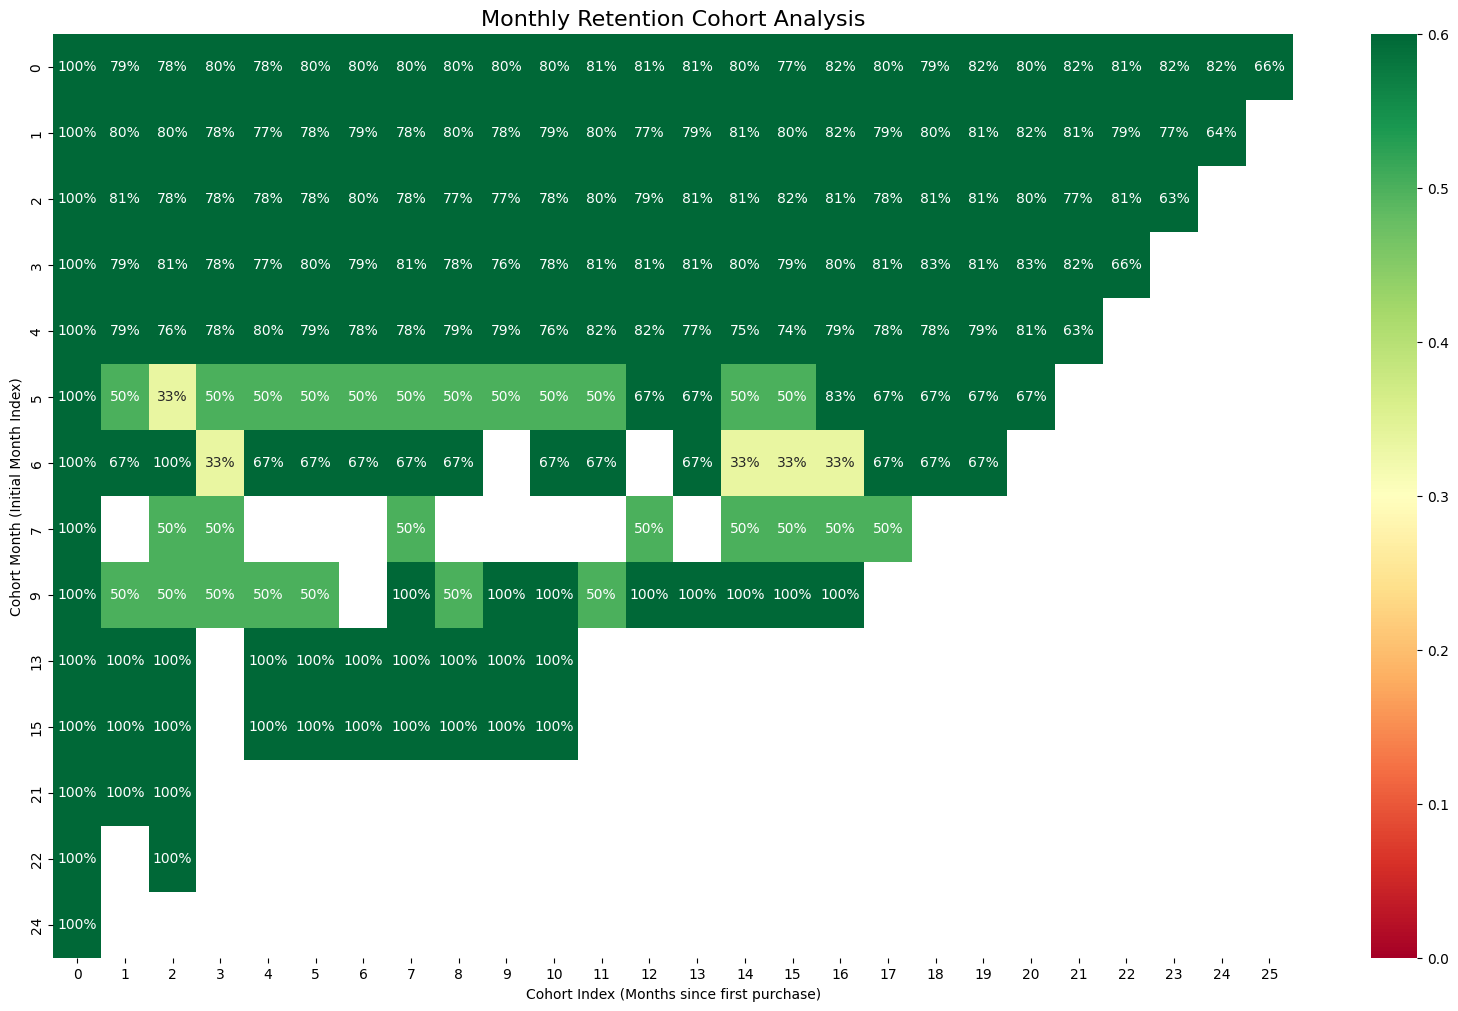

In [ ]:
df = transactions_master.copy()

df['cohort_month'] = df.groupby('household_key')['global_month_idx'].transform('min')
df['cohort_index'] = df['global_month_idx'] - df['cohort_month']

cohort_data = df.groupby(['cohort_month', 'cohort_index'])['household_key'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='cohort_month',
                                     columns='cohort_index',
                                     values='household_key')

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

plt.figure(figsize=(20, 12))
plt.title('Monthly Retention Cohort Analysis', fontsize=16)

sns.heatmap(retention, 
            annot=True, 
            fmt='.0%', 
            cmap='RdYlGn', 
            vmin=0.0, 
            vmax=0.6)

plt.xlabel('Cohort Index (Months since first purchase)')
plt.ylabel('Cohort Month (Initial Month Index)')
plt.show()


#### COHORT INSIGHT
1. **High Loyalty in Early Groups (Cohorts 0-4):** 
- Customers who joined at the very beginning are extremely loyal. About 80% of them return every single month. They are the "backbone" of our revenue.
2. **Danger Zone for Newcomers (Cohorts 5-9):** 
- People who joined later (from Month 5 onwards) are much harder to keep. They often leave after just 1 or 2 months. We need to find out why they aren't as happy as the old customers.

In [ ]:
new_customers_df = df.drop_duplicates(subset=['household_key'])[['household_key', 'cohort_month']]

# Step 2: Aggregate the count of new customers per cohort month
monthly_acquisition = new_customers_df.groupby('cohort_month')['household_key'].nunique().reset_index()
monthly_acquisition.columns = ['cohort_month', 'new_customer_count']

# Step 3: Map time labels for visualization (1-X, 2-X, etc.)
year_naming = {0: 'X', 1: 'Y', 2: 'Z'}
monthly_acquisition['year_offset'] = monthly_acquisition['cohort_month'] // 12
monthly_acquisition['month_in_year'] = (monthly_acquisition['cohort_month'] % 12) + 1
monthly_acquisition['date_label'] = (
    monthly_acquisition['month_in_year'].astype(str) + '-' + 
    monthly_acquisition['year_offset'].map(year_naming)
)

# Sort by cohort_month to ensure the timeline is correct
monthly_acquisition = monthly_acquisition.sort_values('cohort_month')

# --- 2. VISUALIZATION ---

# Create Line Graph
fig = px.line(
    monthly_acquisition, 
    x='date_label', 
    y='new_customer_count',
    markers=True,
    text='new_customer_count'
)

# Customize Line and Markers aesthetics
fig.update_traces(
    line_color=c['blue_medium'],
    line_width=3,
    marker=dict(size=10, color=c['accent_gold'], line=dict(width=2, color=c['blue_dark'])),
    textposition="top center"
)

# Apply custom branding style
fig = apply_my_style(
    fig, 
    title="NEW CUSTOMER ACQUISITION TREND", 
    subtitle="Monthly count of new households based on their first purchase month (Cohort Month)"
)

# Adjust layout specifics
fig.update_layout(
    xaxis_title="Month-Year Cycle (Cohort)",
    yaxis_title="Number of New Customers",
    xaxis=dict(tickangle=0)
)

fig.show()

#### COHORT INSIGHT 02: 

**1. The Power of Early Cohorts (T1 - T4: The Backbone)**
*   **Massive Volume:** These months account for **over 90%** of the total customer base, peaking at 681 new households in Month 4.
*   **Elite Retention:** They maintain an extraordinary retention rate of **75% – 82%** for over two years. 
*   **Strategic Role:** These are your "Power Users." They provide the steady, predictable revenue that keeps the business alive.

**2. Critical Issues with Late Cohorts (T5 onwards: The Risk)**
*   **Acquisition Collapse:** From Month 5, new customer sign-ups plummeted from hundreds to single digits (6, 3, 2...). Growth has essentially stopped.
*   **Fragile Loyalty:** Unlike the early groups, these customers are "leaky." Retention often drops to **33% – 50%** in the first few months.
*   **Statistical Noise:** The 100% rates seen in very late cohorts (T13-T24) are misleading due to tiny sample sizes (often only 1 or 2 people).

 **3. Final Conclusion**
*   **Business Health:** The store is entirely dependent on its **Legacy Customers (T1-T4)**. 
*   **The Red Flag:** The business is failing to convert new sign-ups into loyal shoppers. If the T1-T4 group ever churns, the business will collapse because there is no new "loyal blood" to replace them.
*   **Action:** Immediately prioritize **retention for T1-T4** and investigate why the "New User Experience" failed for everyone joining after Month 5.

In [ ]:
# --- 1. DATA PREPROCESSING ---

# Step 1: Get unique baskets per household with their earliest day
order_sequence = (
    transactions_master.groupby(['household_key', 'BASKET_ID'])['DAY']
    .min()
    .reset_index()
)

# Step 2 & 3: Sort by day and assign order sequence number (1, 2, 3...)
order_sequence['order_number'] = (
    order_sequence.sort_values(['household_key', 'DAY'])
    .groupby('household_key')
    .cumcount() + 1
)

# Step 4: Count unique households that reached each order milestone (Order 1 to 10)
funnel_data = []
for i in range(1, 11):
    count = order_sequence[order_sequence['order_number'] == i]['household_key'].nunique()
    funnel_data.append({'Order_Stage': f'Order {i}', 'Customer_Count': count})

df_funnel = pd.DataFrame(funnel_data)

# --- 2. INSIGHT CALCULATIONS ---

# Calculate Retention between Order 3 and Order 4
count_o3 = df_funnel.loc[df_funnel['Order_Stage'] == 'Order 3', 'Customer_Count'].values[0]
count_o4 = df_funnel.loc[df_funnel['Order_Stage'] == 'Order 4', 'Customer_Count'].values[0]
retention_3_to_4 = (count_o4 / count_o3) * 100

# Calculate largest drop-off rate
df_funnel['pct_change'] = df_funnel['Customer_Count'].pct_change() * 100
max_drop_idx = df_funnel['pct_change'].idxmin()
max_drop_stage = df_funnel.iloc[max_drop_idx]['Order_Stage']
max_drop_val = abs(df_funnel.iloc[max_drop_idx]['pct_change'])

# --- 3. VISUALIZATION ---

# Define a professional gradient palette using your blue tones
gradient_colors = [
    '#0F2854', '#15366B', '#1B4482', '#215299', '#2760B0', 
    '#2D6EC7', '#4988C4', '#66A2D1', '#83BCDE', '#BDE8F5'
]

fig = go.Figure(go.Funnel(
    y=df_funnel['Order_Stage'],
    x=df_funnel['Customer_Count'],
    textinfo="value+percent initial+percent previous",
    marker=dict(
        color=gradient_colors,
        line=dict(width=2, color='white')
    ),
    connector=dict(line=dict(color=c['gray_medium'], width=1))
))

# Apply branding style
fig = apply_my_style(
    fig, 
    title="CUSTOMER LOYALTY THRESHOLD FUNNEL", 
    subtitle="Analysis of customer retention across the first 10 orders"
)

fig.update_layout(
    width=1000, 
    height=700,
    yaxis=dict(showline=False)
)

fig.show()

# Print Insights
print(f"--- LOYALTY INSIGHTS ---")
print(f"1. Largest Drop-off Point: {max_drop_stage} (Lost {max_drop_val:.1f}% of previous customers).")
print(f"2. Order 3 to 4 Conversion: {retention_3_to_4:.1f}% of customers who made 3 orders will proceed to the 4th.")

--- LOYALTY INSIGHTS ---
1. Largest Drop-off Point: Order 10 (Lost 0.9% of previous customers).
2. Order 3 to 4 Conversion: 99.7% of customers who made 3 orders will proceed to the 4th.


In [ ]:
campaign_table.head()

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [ ]:
campaign_desc.head(50)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684
5,TypeB,21,624,656
6,TypeB,22,624,656
7,TypeA,18,587,642
8,TypeB,19,603,635
9,TypeB,17,575,607


In [ ]:
coupon.head()

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [ ]:
coupon_redempt.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18
